In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error , root_mean_squared_error

In [2]:
dataset=pd.read_csv('insurance.csv')

In [3]:
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
dataset.shape

(1338, 7)

In [5]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
age	sex	bmi	children	smoker	region	charges

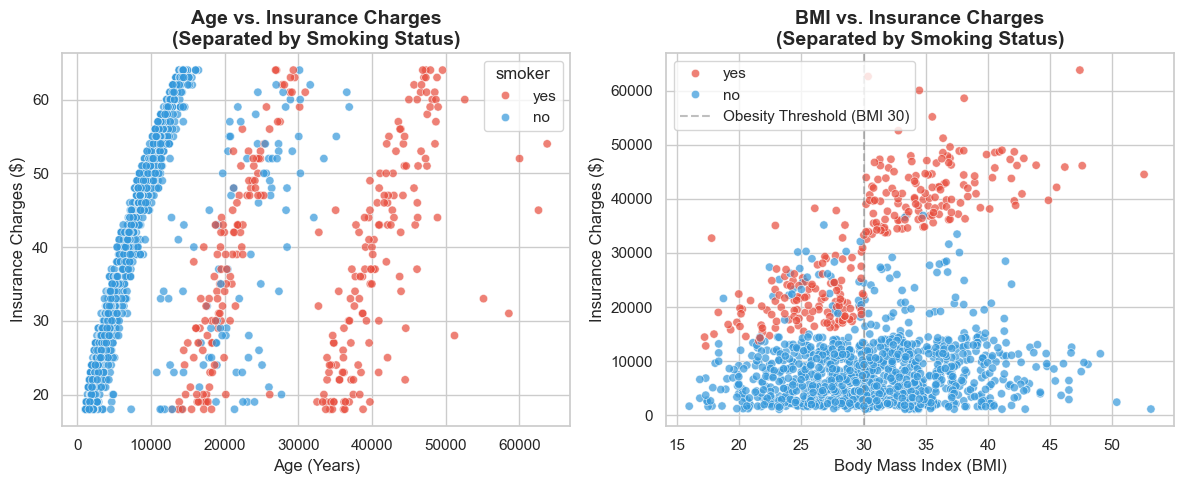

In [19]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Plot 1: Age vs. Charges (Colored by Smoking Status)
sns.scatterplot(
    data=dataset, 
    x='charges', 
    y='age', 
    hue='smoker', 
    palette=['#e74c3c', '#3498db'], # Red for Yes, Blue for No
    alpha=0.7, 
    ax=axes[0]
)
axes[0].set_title('Age vs. Insurance Charges\n(Separated by Smoking Status)', fontsize=14, weight='bold')
axes[0].set_xlabel('Age (Years)', fontsize=12)
axes[0].set_ylabel('Insurance Charges ($)', fontsize=12)

# Plot 2: BMI vs. Charges (Colored by Smoking Status)
sns.scatterplot(
    data=dataset, 
    x='bmi', 
    y='charges', 
    hue='smoker', 
    palette=['#e74c3c', '#3498db'], 
    alpha=0.7, 
    ax=axes[1]
)
# Add a vertical line at BMI 30 to indicate the threshold for obesity
axes[1].axvline(30, color='gray', linestyle='--', alpha=0.5, label='Obesity Threshold (BMI 30)')
axes[1].set_title('BMI vs. Insurance Charges\n(Separated by Smoking Status)', fontsize=14, weight='bold')
axes[1].set_xlabel('Body Mass Index (BMI)', fontsize=12)
axes[1].set_ylabel('Insurance Charges ($)', fontsize=12)
axes[1].legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

In [23]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# 4. Create preprocessing steps for each data type
numeric_transformer = Pipeline(steps=[ 
    ('scaler', StandardScaler())                  
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) 
])

# 5. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [26]:
X=dataset.drop('charges' , axis=1)
y=dataset['charges']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42)

In [28]:
insurance_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
# Train the model
insurance_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
lr_pred=insurance_pipeline.predict(X_test)

In [31]:
print('Mean Squared Error : ',mean_squared_error(y_test,lr_pred))
print('Root mean Squared Error : ',root_mean_squared_error(y_test,lr_pred))

Mean Squared Error :  34938812.04972172
Root mean Squared Error :  5910.906195307258


* These numbers tell us exactly how far off your pipeline's predictions are from the actual insurance charges. An RMSE of roughly 5,910 means your model is off by an average of 5,910 per patient.